In [1]:
import numpy as np
import astropy.units as u
import glob
import os

import colorsys
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmcrameri.cm as cmc
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

from scipy.signal import find_peaks

In [2]:
# Info to get search results
SOURCE = "2022_CHIME_B2111+46"
OBS_NIGHT = "20220826T064420Z"
RESULTS_DIR = f"/scratch/abernier/pulsar_data/search_results/{SOURCE}/{OBS_NIGHT}"
SETTINGS = "timeavg391_nfiles65_start160_RFI1.7mean1.3std"
PARAM = "delay_ns"  # Specify which parameter was varied in the search results to plot
# PARAM_LABEL = "Downsampling Factor"  # Label for the x-axis corresponding to the varied parameter (e.g., 'Downsampling Factor', 'DM [pc/cm^3]')
PARAM_DIR = f"{RESULTS_DIR}/{SETTINGS}/{PARAM}/"
BURST_LIMS = [1.10, 1.15]
if BURST_LIMS == [0]:
    BURST_LIMS = None  # interpret burst_lims of 0 as no limits (i.e. use full time range for plots)

# Search result files
METADATA_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_metadata.npz")), key=len)
TIMINGS_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_timings.npz")), key=len)
DATA_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_arrays.npz")), key=len)
NFILES = len(DATA_FILES)  # number of files to plot
DATA_FILES_UNIQUE = True   # determines if masked+normalized stokes data is the same for all values of the varied params or not
                           # True if data is unique, false if data changes with each run of param

# Save directory for figures
SOURCE_AND_NIGHT = f"{RESULTS_DIR.split('/')[-2]}/{RESULTS_DIR.split('/')[-1]}"
SAVE_FIG_DIR = f'/scratch/abernier/rm-search-Bernier-2025/figures/{SOURCE_AND_NIGHT}/{SETTINGS}/{PARAM}/'
os.makedirs(os.path.dirname(SAVE_FIG_DIR), exist_ok=True)

In [3]:
# Open Results
# ------------------------------------------------------------------------------
param_list = []
data = {}
metadata = {}
timings = {}

for data_file, metadata_file, timings_file in zip(DATA_FILES, METADATA_FILES, TIMINGS_FILES):
    # Get parameter value from filename
    filename = os.path.basename(data_file)  # format: param_name{param_value}_arrays.npz
    param_value = float(filename.split("_")[-2]) 
    param_list.append(param_value)

    # Load data
    with np.load(data_file, allow_pickle=True) as df:
        data_dict = {k: df[k] for k in df.files}
        data[param_value] = data_dict

    # Load metadata
    with np.load(metadata_file, allow_pickle=True) as mf:
        metadata[param_value] = mf['metadata'][0]

    # Load timings
    with np.load(timings_file, allow_pickle=True) as tf:
        timings[param_value] = tf['timings'][0]

param_list = sorted(param_list)

In [4]:
# Get true RMs (using 1st file)
# ------------------------------------------------------------------------------
rm_true = list(metadata[param_list[0]]['true_rms_rad_m2'].value)  # true RM of real data
if metadata[param_list[0]]['sim_flag']:
    sim_rm = metadata[param_list[0]]['sim_params']["rm"]  # true RM of injected bursts
    rm_true.append(sim_rm.value)
rm_true = np.array(rm_true)  # for now: assume shape is (1,)
rm_true = rm_true[0]

In [5]:
# source info
source_P0 = 1.014684793189 * u.s  # pulse period
source_W50 = 60.5 * u.ms  # pulse width
tol = source_W50 + 10*u.ms  # min distance bw peaks for them to be counted as 2 peaks (in ms)

# Data info
p = -2.0
fdf = data[p]['FDF_arr']  # shape (Ntimes, Nphi)
phi_arr = data[p]['phi_array']  # shape (Nphi,)
time_arr = data[p]['time_slice_arr']  # shape (Ntimes,)
phi_mask = np.abs(phi_arr) > 10 # exclude phi values between -10 and 10
fdf[:,~phi_mask] = np.nan
time_length = time_arr[-1]*u.s - time_arr[0]*u.s

In [6]:
def downsample_time_mean(data, time, factor):
    """
    Downsample data along the time axis by some factor (number of time bins per group)
    """
    # Trim time axis so it's divisible by 'factor'
    Ntime = data.shape[0]
    Ntime_trimmed = (Ntime // factor) * factor
    trimmed_data = data[:Ntime_trimmed]
    trimmed_time = time[:Ntime_trimmed]

    # Group consecutive time samples into bins of size 'factor'
    # New shape: (Ngroups, factor, Nphi)
    grouped_data = trimmed_data.reshape(-1, factor, data.shape[1])
    grouped_time = trimmed_time.reshape(-1, factor)

    # Average within each group (collapse the 'factor' axis)
    downsampled_data = grouped_data.mean(axis=1)
    downsampled_time = grouped_time.mean(axis=1)
    
    return downsampled_data, downsampled_time

In [58]:
dt_fdf = metadata[p]['dt_rm_ms']
peak_search_downsamp_factor = 8
snr_cutoff = 10

print(f'Downsampling to {dt_fdf*peak_search_downsamp_factor:.3f} ms')
print(f'Tolerance to differentiate pulses: {tol:.1f}')
print(f'S/N cutoff: {snr_cutoff}')

downsampled_fdf, downsampled_time = downsample_time_mean(
    fdf,
    time_arr,
    peak_search_downsamp_factor
)

# Find peaks
detections = []
for t_ind, fdf_slice in enumerate(downsampled_fdf):
    fdf_slice = abs(fdf_slice) # (Nphi,)
    median = np.nanmedian(fdf_slice, axis=0)
    sigma = np.nanstd(fdf_slice, axis=0)    
    snr_slice = np.divide(  # to avoid /0
        fdf_slice - median,
        sigma,
        out=np.zeros_like(fdf_slice),
        where=(sigma != 0) & ~np.isnan(fdf_slice)
    )  # shape (Nphi,)
    
    # peaks, properties = find_peaks(fdf_slice, prominence=10*median)
    peaks, properties = find_peaks(snr_slice, prominence=snr_cutoff)

    if len(peaks) == 0:
        continue

    detections.append({
        't_ind': t_ind,
        'time': downsampled_time[t_ind],
        'peaks': peaks,
        'median': median,
        # 'properties': properties,
    })

Downsampling to 8.008 ms
Tolerance to differentiate pulses: 70.5 ms
S/N cutoff: 10


In [59]:
# detections

In [60]:
# Separate peaks into distinct bursts
bursts = []  # list of dicts: 1 element = 1 burst, dicts = all peaks found within burst
burst_start_time = None
current_burst = []

for det in detections: # go through detected peaks

    if burst_start_time is None:
        burst_start_time = det["time"]
        current_burst = [det]
        continue

    dt = (det["time"] - burst_start_time) * u.s  # how far are we from the start of this pulse?
    if dt <= tol:  # still in same burst
        current_burst.append(det)  # append peaks to current burst info
    else:  # new burst! 
        bursts.append(current_burst)
        burst_start_time = det["time"]  # update start time
        current_burst = [det]  # start new burst

# make sure we add last burst to list of bursts
if len(current_burst):
    bursts.append(current_burst)

In [61]:
print(f"FDF time length: {time_length:.3f}")

# expected pulses
num_pulses_expected = time_length / source_P0  # num of expected pulses in data read
print(f"Expecting ~{int(num_pulses_expected)} pulses in data")

# pulses found
print(f"Found {len(bursts)} pulse(s)")

FDF time length: 5.574 s
Expecting ~5 pulses in data
Found 1 pulse(s)


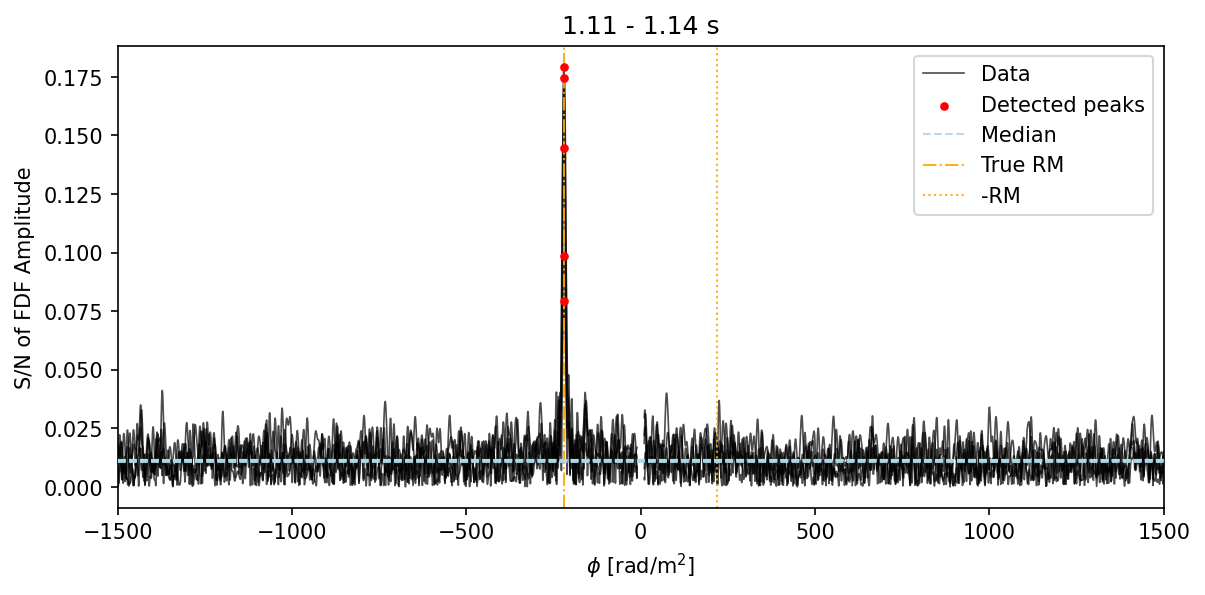

In [62]:
for i in range(len(bursts)):
    burst = bursts[i]
    plt.figure(figsize=(9,4), dpi=150)
    plt.title(f"{burst[0]['time']:.2f} - {burst[-1]['time']:.2f} s")
    plt.ylabel("S/N of FDF Amplitude")
    plt.xlabel(r'$\phi$ [rad/m$^2$]')

    # plot all slices with peaks detected
    for det in burst:
        t_ind = det["t_ind"]
        peaks = det["peaks"]
        fdf_line, = plt.plot(phi_arr, np.abs(downsampled_fdf[t_ind]), c='k', lw=0.8, alpha=0.7, zorder=1)
        peak_marker = plt.scatter(phi_arr[peaks], np.abs(downsampled_fdf[t_ind])[peaks], c='red', s=10, zorder=3)
        median_line = plt.axhline(y=det["median"], c='lightblue', ls='--', alpha=0.9, lw=1, zorder=3)

    # rm and median lines
    rm_line = plt.axvline(x=rm_true, c='orange', ls='-.', alpha=0.9, lw=1, zorder=2)
    neg_rm_line = plt.axvline(x=-rm_true, c='orange', ls=':', alpha=0.9, lw=1, zorder=2)

    # legend
    plt.legend(
        handles=[fdf_line, peak_marker, median_line, rm_line, neg_rm_line], 
        labels=['Data', 'Detected peaks', 'Median', 'True RM', '-RM'],
        loc="upper right")
    
    plt.xlim(np.min(phi_arr), np.max(phi_arr))
    plt.show()